In [1]:
#!pip install openpyxl

In [2]:
#import sys
#print(sys.executable)

In [3]:
#import sys
#!{sys.executable} -m pip install openpyxl

In [4]:
#import openpyxl
#print(openpyxl.__version__)

In [5]:
import pandas as pd

df = pd.read_excel("Dengue_Cleaned_ML.xlsx", engine="openpyxl")
df.head()

,year,week,month,dengue_cases,outbreak_level,temp_max_c,temp_min_c,temp_mean_c,feelslikemax,feelslikemin,...,wind_speed_kmh,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,stations
0,2024,1,1,209,Low,31.8774,24.4419,NaN,NaN,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024,2,1,463,Medium,31.8774,24.4419,NaN,NaN,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024,3,1,353,Medium,31.8774,24.4419,NaN,NaN,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024,4,1,354,Medium,31.8774,24.4419,NaN,NaN,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024,5,1,314,Medium,31.8774,24.4419,NaN,NaN,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("Dataset shape:", df.shape)
df.columns

Dataset shape: (708, 26)


Index(['year', 'week', 'month', 'dengue_cases', 'outbreak_level', 'temp_max_c',
       'temp_min_c', 'temp_mean_c', 'feelslikemax', 'feelslikemin',
       'feelslike', 'dew', 'humidity_pct', 'rainfall_mm', 'precipprob',
       'precipcover', 'wind_speed_kmh', 'winddir', 'sealevelpressure',
       'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex',
       'conditions', 'stations'],
      dtype='object')

In [7]:
df.isnull().sum()

year                  0
week                  0
month                 0
dengue_cases          0
outbreak_level        0
temp_max_c            0
temp_min_c            4
temp_mean_c         106
feelslikemax        106
feelslikemin        106
feelslike           106
dew                 106
humidity_pct          0
rainfall_mm           0
precipprob          106
precipcover         106
wind_speed_kmh        0
winddir             106
sealevelpressure    106
cloudcover          106
visibility          106
solarradiation      106
solarenergy         106
uvindex             106
conditions          106
stations            106
dtype: int64

In [8]:
df.shape

(708, 26)

In [9]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percentage
temp_min_c,4,0.564972
temp_mean_c,106,14.971751
feelslikemax,106,14.971751
feelslikemin,106,14.971751
feelslike,106,14.971751
dew,106,14.971751
precipprob,106,14.971751
precipcover,106,14.971751
winddir,106,14.971751
sealevelpressure,106,14.971751


In [10]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols] = df[numeric_cols].interpolate(method="linear")
df[numeric_cols] = df[numeric_cols].ffill()
df[numeric_cols] = df[numeric_cols].bfill()

In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
df["outbreak_level"].value_counts()

outbreak_level
Medium    354
Low       177
High      177
Name: count, dtype: int64

In [13]:
df.dtypes

year                  int64
week                  int64
month                 int64
dengue_cases          int64
outbreak_level       object
temp_max_c          float64
temp_min_c          float64
temp_mean_c         float64
feelslikemax        float64
feelslikemin        float64
feelslike           float64
dew                 float64
humidity_pct        float64
rainfall_mm         float64
precipprob          float64
precipcover         float64
wind_speed_kmh      float64
winddir             float64
sealevelpressure    float64
cloudcover          float64
visibility          float64
solarradiation      float64
solarenergy         float64
uvindex             float64
conditions          float64
stations            float64
dtype: object

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["outbreak_level_encoded"] = label_encoder.fit_transform(df["outbreak_level"])

print("Target classes:", list(label_encoder.classes_))
print(df[["outbreak_level", "outbreak_level_encoded"]].drop_duplicates())

Target classes: ['High', 'Low', 'Medium']
    outbreak_level  outbreak_level_encoded
0              Low                       1
1           Medium                       2
109           High                       0


## Feature and Target Split

In [16]:
# Feature and Target Split

X = df.drop(columns=[
    "outbreak_level",
    "outbreak_level_encoded",
    "dengue_cases",
    "conditions",
    "stations"
])

y = df["outbreak_level_encoded"]

# Time-based train-test split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Feature columns:")
print(X.columns.tolist())

X shape: (708, 22)
y shape: (708,)
Train shape: (566, 22)
Test shape: (142, 22)
Feature columns:
['year', 'week', 'month', 'temp_max_c', 'temp_min_c', 'temp_mean_c', 'feelslikemax', 'feelslikemin', 'feelslike', 'dew', 'humidity_pct', 'rainfall_mm', 'precipprob', 'precipcover', 'wind_speed_kmh', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex']


In [17]:
# Clean feature set - remove target, leakage column, and text columns

columns_to_drop = [
    "outbreak_level",
    "outbreak_level_encoded",
    "dengue_cases",
    "conditions",
    "stations"
]

X = df.drop(columns=columns_to_drop, errors="ignore")
y = df["outbreak_level_encoded"]

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("conditions in X:", "conditions" in X.columns)
print("stations in X:", "stations" in X.columns)

print("X shape:", X.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Feature columns:")
print(X.columns.tolist())

conditions in X: False
stations in X: False
X shape: (708, 22)
Train shape: (566, 22)
Test shape: (142, 22)
Feature columns:
['year', 'week', 'month', 'temp_max_c', 'temp_min_c', 'temp_mean_c', 'feelslikemax', 'feelslikemin', 'feelslike', 'dew', 'humidity_pct', 'rainfall_mm', 'precipprob', 'precipcover', 'wind_speed_kmh', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex']


In [18]:
"conditions" in X.columns, "stations" in X.columns

(False, False)

## Random Forest Baseline Model

In [19]:
# Random Forest Baseline Model

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Sort dataset by time
df = df.sort_values(["year", "week"]).reset_index(drop=True)

# 2. Encode target column: Low / Medium / High -> numbers
label_encoder = LabelEncoder()
df["outbreak_level_encoded"] = label_encoder.fit_transform(df["outbreak_level"])

print("Target classes:", list(label_encoder.classes_))

# 3. Select features and target
# Drop:
# - outbreak_level: original target column
# - outbreak_level_encoded: encoded target column
# - dengue_cases: possible data leakage column
# - conditions, stations: text/categorical columns not used in baseline numerical model

X = df.drop(columns=[
    "outbreak_level",
    "outbreak_level_encoded",
    "dengue_cases",
    "conditions",
    "stations"
], errors="ignore")

y = df["outbreak_level_encoded"]

print("Feature columns:")
print(X.columns.tolist())

print("conditions in X:", "conditions" in X.columns)
print("stations in X:", "stations" in X.columns)

print("X shape:", X.shape)
print("y shape:", y.shape)

# 4. Time-based train-test split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

# 5. Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

# 6. Make predictions
y_pred = rf_model.predict(X_test)

# 7. Evaluate model
accuracy = accuracy_score(y_test, y_pred)

print("\nRandom Forest Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1, 2],
    target_names=label_encoder.classes_,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1, 2]
))

Target classes: ['High', 'Low', 'Medium']
Feature columns:
['year', 'week', 'month', 'temp_max_c', 'temp_min_c', 'temp_mean_c', 'feelslikemax', 'feelslikemin', 'feelslike', 'dew', 'humidity_pct', 'rainfall_mm', 'precipprob', 'precipcover', 'wind_speed_kmh', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex']
conditions in X: False
stations in X: False
X shape: (708, 22)
y shape: (708,)
Train size: (566, 22)
Test size: (142, 22)

Train target distribution:
outbreak_level_encoded
2    258
1    177
0    131
Name: count, dtype: int64

Test target distribution:
outbreak_level_encoded
2    96
0    46
Name: count, dtype: int64

Random Forest Accuracy: 0.6971830985915493

Classification Report:
              precision    recall  f1-score   support

        High       0.55      0.46      0.50        46
         Low       0.00      0.00      0.00         0
      Medium       0.76      0.81      0.79        96

    accuracy                       

In [20]:
print("Train target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

print("\nClass mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "=", cls)

Train target distribution:
outbreak_level_encoded
2    258
1    177
0    131
Name: count, dtype: int64

Test target distribution:
outbreak_level_encoded
2    96
0    46
Name: count, dtype: int64

Class mapping:
0 = High
1 = Low
2 = Medium


In [21]:
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1, 2],
    target_names=label_encoder.classes_,
    zero_division=0
))


Classification Report:
              precision    recall  f1-score   support

        High       0.55      0.46      0.50        46
         Low       0.00      0.00      0.00         0
      Medium       0.76      0.81      0.79        96

    accuracy                           0.70       142
   macro avg       0.44      0.42      0.43       142
weighted avg       0.70      0.70      0.69       142



## Random Forest Feature Importance

In [22]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
14,wind_speed_kmh,0.099149
18,visibility,0.088487
8,feelslike,0.080653
1,week,0.065110
17,cloudcover,0.061161
7,feelslikemin,0.058302
16,sealevelpressure,0.053650
10,humidity_pct,0.053641
5,temp_mean_c,0.051977
11,rainfall_mm,0.048636


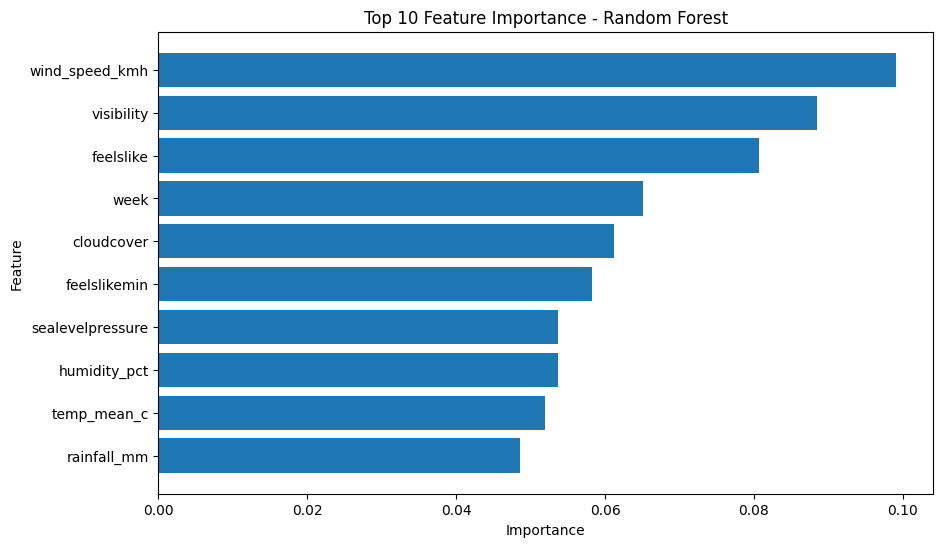

In [23]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

In [24]:
rf_accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Baseline Accuracy:", rf_accuracy)

Random Forest Baseline Accuracy: 0.6971830985915493


In [25]:
#!pip install xgboost

In [26]:
#import xgboost
#print(xgboost.__version__)

In [27]:
#import sys
#!{sys.executable} -m pip install xgboost

## XGBoost Model

In [28]:
# XGBoost Model

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss"
)

# 2. Train model using clean X_train and y_train
xgb_model.fit(X_train, y_train)

# 3. Predict using X_test
xgb_pred = xgb_model.predict(X_test)

# 4. Evaluate model
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    xgb_pred,
    labels=[0, 1, 2],
    target_names=label_encoder.classes_,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    xgb_pred,
    labels=[0, 1, 2]
))

XGBoost Accuracy: 0.5774647887323944

Classification Report:
              precision    recall  f1-score   support

        High       0.36      0.35      0.35        46
         Low       0.00      0.00      0.00         0
      Medium       0.70      0.69      0.69        96

    accuracy                           0.58       142
   macro avg       0.35      0.35      0.35       142
weighted avg       0.59      0.58      0.58       142


Confusion Matrix:
[[16  2 28]
 [ 0  0  0]
 [29  1 66]]


In [29]:
from sklearn.metrics import f1_score, precision_score, recall_score
import pandas as pd

rf_accuracy = accuracy_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

rf_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
xgb_f1 = f1_score(y_test, xgb_pred, average="weighted", zero_division=0)

rf_precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
xgb_precision = precision_score(y_test, xgb_pred, average="weighted", zero_division=0)

rf_recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
xgb_recall = recall_score(y_test, xgb_pred, average="weighted", zero_division=0)

model_comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy],
    "Precision": [rf_precision, xgb_precision],
    "Recall": [rf_recall, xgb_recall],
    "Weighted F1-score": [rf_f1, xgb_f1]
})

model_comparison

,Model,Accuracy,Precision,Recall,Weighted F1-score
0,Random Forest,0.697183,0.696006,0.697183,0.694622
1,XGBoost,0.577465,0.589858,0.577465,0.583596


In [34]:
import joblib

joblib.dump(rf_model, "random_forest_dengue_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [ ]:
## Sample Prediction Using the Best Model

In [35]:
# Sample prediction using one row from test set

sample = X_test.iloc[[0]]

prediction = rf_model.predict(sample)
predicted_label = label_encoder.inverse_transform(prediction)

actual_label = label_encoder.inverse_transform([y_test.iloc[0]])

print("Predicted outbreak level:", predicted_label[0])
print("Actual outbreak level:", actual_label[0])

Predicted outbreak level: High
Actual outbreak level: High


In [36]:
# Prediction probability

probabilities = rf_model.predict_proba(sample)

probability_df = pd.DataFrame(
    probabilities,
    columns=label_encoder.classes_
)

probability_df

,High,Low,Medium
0,0.62,0.0,0.38


In [37]:
# Test first 10 samples

sample_data = X_test.iloc[:10]

predictions = rf_model.predict(sample_data)
predicted_labels = label_encoder.inverse_transform(predictions)
actual_labels = label_encoder.inverse_transform(y_test.iloc[:10])

result_df = pd.DataFrame({
    "Actual": actual_labels,
    "Predicted": predicted_labels
})

result_df

,Actual,Predicted
0,High,High
1,High,High
2,High,High
3,High,High
4,High,Low
5,High,High
6,Medium,High
7,High,Medium
8,High,High
9,High,High


In [ ]:
## Saving the Best Model

In [38]:
import joblib

joblib.dump(rf_model, "random_forest_dengue_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [39]:
import joblib
import pandas as pd

# 1. Save model features/order
joblib.dump(X_train.columns.tolist(), "model_features.pkl")

# 2. Save model comparison results
model_comparison.to_csv("model_comparison_results.csv", index=False)

# 3. Save feature importance results
feature_importance.to_csv("feature_importance.csv", index=False)

# 4. Save actual vs predicted output
predictions_output = pd.DataFrame({
    "Actual": label_encoder.inverse_transform(y_test),
    "Predicted": label_encoder.inverse_transform(y_pred)
})

predictions_output.to_csv("predictions_output.csv", index=False)

# 5. Save cleaned ML-ready dataset as CSV
df.to_csv("Dengue_ML_Ready.csv", index=False)

print("All output files saved successfully.")

All output files saved successfully.


In [2]:
import pandas as pd

In [3]:
df_ready = pd.read_csv("Dengue_ML_Ready.csv")

print(df_ready.shape)
print(df_ready.isnull().sum().sum())
df_ready.head()

(708, 27)
0


,year,week,month,dengue_cases,outbreak_level,temp_max_c,temp_min_c,temp_mean_c,feelslikemax,feelslikemin,...,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,stations,outbreak_level_encoded
0,2024,1,1,209,Low,31.8774,24.4419,28.709863,39.757808,25.317808,...,175.595342,1007.911781,50.747945,3.789863,208.097808,17.973699,7.232877,2.558904,1.19726,1
1,2024,2,1,463,Medium,31.8774,24.4419,28.709863,39.757808,25.317808,...,175.595342,1007.911781,50.747945,3.789863,208.097808,17.973699,7.232877,2.558904,1.19726,2
2,2024,3,1,353,Medium,31.8774,24.4419,28.709863,39.757808,25.317808,...,175.595342,1007.911781,50.747945,3.789863,208.097808,17.973699,7.232877,2.558904,1.19726,2
3,2024,4,1,354,Medium,31.8774,24.4419,28.709863,39.757808,25.317808,...,175.595342,1007.911781,50.747945,3.789863,208.097808,17.973699,7.232877,2.558904,1.19726,2
4,2024,5,1,314,Medium,31.8774,24.4419,28.709863,39.757808,25.317808,...,175.595342,1007.911781,50.747945,3.789863,208.097808,17.973699,7.232877,2.558904,1.19726,2
